# Multi-Agent Marketing Intelligence System

A multi-agent system built with the **Gemini API** (reasoning / generation) and the **Tavily API** (live web search) for lead discovery.

## The four agents

| # | Agent | Responsibility |
|---|-------|-----------------|
| 1 | `MarketingAgent` | Builds a cross-platform marketing strategy and drafts platform-native posts (Instagram, LinkedIn, X/Twitter, Facebook, YouTube). |
| 2 | `LeadGenAgent` | Uses live web search (Tavily) to discover and qualify prospective leads/partners against an Ideal Customer Profile (ICP). |
| 3 | `CampaignAgent` | Writes campaign/poster copy, renders a designed poster image, and drafts audience-engagement replies. |
| 4 | `RevenuePredictorAgent` | Forecasts revenue, cost and profit/loss from historical financial data and writes an executive summary. |

All four agents share one **memory blackboard** and are coordinated by a fifth component, the `OrchestratorAgent`, which is the actual "multi-agent system" layer: given one plain-English business goal, it decides which agents to call, in which order, and stitches their outputs into a single report.

## Architecture

```
                       ┌─────────────────────┐
   business goal  ───▶ │  OrchestratorAgent   │ ───▶ final report
                       └─────────┬───────────┘
                                 │ plans & routes
        ┌───────────┬───────────┼───────────┬────────────────┐
        ▼           ▼           ▼           ▼
 MarketingAgent LeadGenAgent CampaignAgent RevenuePredictorAgent
        │           │           │           │
        └─────── shared AgentMemory (blackboard) ─────────────┘
```

## Tech stack (100% free-tier)

- **LLM reasoning / content generation:** Google Gemini API (`google-genai` SDK, `gemini-3.6-flash`)
- **Live web search for leads:** Tavily API (`tavily-python`)
- **Data / forecasting:** pandas, scikit-learn, matplotlib
- **Poster rendering:** Pillow (PIL)

> Run the cells in order, top to bottom. Setup instructions (getting API keys, adding them to Colab, uploading your own data) are provided separately in plain text — this notebook assumes both keys are already saved as Colab secrets named `GEMINI_API_KEY` and `TAVILY_API_KEY`.


## Step 1 — Install dependencies

In [ ]:
!pip install -q -U google-genai tavily-python pandas==2.2.3 matplotlib scikit-learn google-auth==2.49.0

## Step 2 — Configure API clients

Reads `GEMINI_API_KEY` and `TAVILY_API_KEY` from **Colab Secrets** (recommended, keys never appear in the notebook text) and falls back to environment variables if you're running this outside Colab.


In [ ]:
pip install pillow

In [ ]:
import os, json, re, time
from datetime import datetime, timedelta

from google import genai
from google.genai import types as genai_types
from tavily import TavilyClient

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from sklearn.linear_model import LinearRegression

# --- Load credentials -------------------------------------------------------
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    TAVILY_API_KEY = userdata.get('TAVILY_API_KEY')
except Exception:
    GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
    TAVILY_API_KEY = os.environ.get('TAVILY_API_KEY')

assert GEMINI_API_KEY, "GEMINI_API_KEY not found. Add it via the key icon in the left sidebar (Secrets)."
assert TAVILY_API_KEY, "TAVILY_API_KEY not found. Add it via the key icon in the left sidebar (Secrets)."

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

# Free-tier friendly model. If you hit a 429 (rate limit) error, switch this
# to "gemini-2.0-flash" or "gemini-flash-lite-latest".
GEMINI_MODEL = "gemini-3.6-flash"

print("Gemini client ready. Tavily client ready.")


Gemini client ready. Tavily client ready.


## Step 3 — Shared agent infrastructure

Every agent below inherits from `BaseAgent` and reads/writes to one shared `AgentMemory` object (a simple "blackboard"). `call_gemini()` is a single, central wrapper so retries, JSON-parsing and error handling are written once and reused by all four agents — this is what keeps the system consistent and easy to extend later.


In [ ]:
class AgentMemory:
    """Shared blackboard: lets agents read outputs produced by other agents."""

    def __init__(self):
        self._store = {}

    def write(self, key, value):
        self._store[key] = value

    def read(self, key, default=None):
        return self._store.get(key, default)

    def keys(self):
        return list(self._store.keys())


def call_gemini(prompt, system_instruction=None, json_mode=False, retries=3):
    """Central wrapper around the Gemini API with retry/backoff and optional
    JSON-only output. Every agent calls this instead of hitting the SDK
    directly, so logging / retry behaviour lives in exactly one place."""
    config = genai_types.GenerateContentConfig(
        system_instruction=system_instruction,
        response_mime_type="application/json" if json_mode else "text/plain",
        temperature=0.6,
    )
    last_err = None
    for attempt in range(retries):
        try:
            response = gemini_client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt,
                config=config,
            )
            text = response.text
            if json_mode:
                cleaned = re.sub(r"^```json|```$", "", text.strip(), flags=re.MULTILINE).strip()
                return json.loads(cleaned)
            return text
        except Exception as e:
            last_err = e
            wait = 2 ** attempt
            print(f"[call_gemini] attempt {attempt + 1}/{retries} failed: {e}. Retrying in {wait}s...")
            time.sleep(wait)
    raise RuntimeError(f"Gemini call failed after {retries} attempts: {last_err}")


class BaseAgent:
    """Common interface so the orchestrator can treat every agent the same way."""

    name = "base_agent"
    description = "Base agent class."

    def __init__(self, memory: AgentMemory):
        self.memory = memory

    def run(self, **kwargs):
        raise NotImplementedError


## Agent 1 — `MarketingAgent`

Builds a cross-platform marketing strategy for a product/audience/goal, and can draft platform-native posts (each platform gets its own tone, length and hashtag conventions).


In [ ]:
class MarketingAgent(BaseAgent):
    name = "marketing_agent"
    description = (
        "Builds cross-platform marketing strategy and drafts platform-native "
        "social/ad copy for a given product, audience and goal."
    )

    def build_strategy(self, product, audience, platforms, goal):
        prompt = f"""
You are a senior marketing strategist. Create a marketing plan.

Product / brand: {product}
Target audience: {audience}
Platforms: {', '.join(platforms)}
Primary goal: {goal}

Return ONLY a JSON object with this exact shape:
{{
  "positioning": "one paragraph positioning statement",
  "key_messages": ["message 1", "message 2", "message 3"],
  "platform_plan": {{
      "<platform name>": {{
          "content_pillars": ["pillar 1", "pillar 2"],
          "posting_cadence": "e.g. 4x/week",
          "tone": "short description of tone/voice for this platform"
      }}
  }},
  "kpis": ["kpi 1", "kpi 2", "kpi 3"]
}}
"""
        strategy = call_gemini(prompt, json_mode=True)
        self.memory.write("marketing_strategy", strategy)
        return strategy

    def generate_post(self, platform, topic, tone="on-brand and energetic"):
        prompt = f"""
Write one ready-to-publish social media post for {platform} about: {topic}.
Tone: {tone}.
Follow {platform}'s conventions (length, hashtags, emojis where appropriate).
Return plain text only, no explanations.
"""
        post = call_gemini(prompt)
        self.memory.write(f"post::{platform}::{topic}", post)
        return post

    def run(self, product, audience, platforms, goal):
        return self.build_strategy(product, audience, platforms, goal)


## Agent 2 — `LeadGenAgent`

Uses **Tavily** to search the live web for organisations/people matching an Ideal Customer Profile (ICP), then uses Gemini to read the search snippets and turn them into a structured, qualified lead list (not just raw links).


In [ ]:
class LeadGenAgent(BaseAgent):
    name = "lead_gen_agent"
    description = (
        "Searches the live web (Tavily) for prospects matching an ICP, then "
        "uses Gemini to qualify and structure them into a lead list."
    )

    def find_leads(self, icp_description, industry, region, max_results=8):
        query = f"{icp_description} in {industry} industry, based in {region}"

        search_results = tavily_client.search(
            query=query,
            search_depth="advanced",
            max_results=max_results,
            include_answer=False,
        )

        raw_hits = [
            {
                "title": r.get("title", ""),
                "url": r.get("url", ""),
                "content": r.get("content", "")[:1000],
            }
            for r in search_results.get("results", [])
        ]

        prompt = f"""
You are a B2B lead-qualification analyst. Below are raw web search results
for the query: "{query}"

Search results (JSON):
{json.dumps(raw_hits, indent=2)}

Ideal Customer Profile: {icp_description}

For each result that plausibly matches the ICP, extract a qualified lead.
Discard irrelevant results (directories, news aggregators with no named
company, etc). Return ONLY a JSON array, each item shaped like:
{{
  "organization": "name",
  "why_it_fits": "one sentence",
  "likely_contact_channel": "e.g. LinkedIn / company contact page / email",
  "confidence": "high | medium | low",
  "source_url": "url"
}}
"""
        leads = call_gemini(prompt, json_mode=True)
        df = pd.DataFrame(leads)
        self.memory.write("leads_df", df)
        self.memory.write("leads_query", query)
        return df

    def run(self, icp_description, industry, region, max_results=8):
        return self.find_leads(icp_description, industry, region, max_results)


## Agent 3 — `CampaignAgent`

Writes poster copy (headline / subheadline / CTA), **renders an actual poster image with Pillow** (no paid image-generation API needed), and drafts on-brand replies to audience comments/DMs for engagement.

> Note on the poster: this renders a clean, templated graphic (background + typography), not an AI-illustrated image — Google's image-generation models (Imagen) sit behind a paid tier. If your boss wants illustrated artwork later, the notebook's design is easy to swap for Imagen or another image API once billing is enabled.


In [ ]:
class CampaignAgent(BaseAgent):
    name = "campaign_agent"
    description = (
        "Writes campaign/poster copy, renders a poster image, and drafts "
        "audience-engagement replies."
    )

    PALETTES = {
        "energetic": [(255, 87, 34), (255, 193, 7)],
        "premium":   [(20, 20, 30), (120, 100, 60)],
        "calm":      [(30, 90, 110), (170, 210, 200)],
    }

    def generate_poster_copy(self, brief):
        prompt = f"""
Write poster copy for this campaign brief: {brief}

Return ONLY JSON:
{{
  "headline": "max 6 words, punchy",
  "subheadline": "max 12 words",
  "cta": "max 4 words, e.g. 'Shop the Sale'",
  "mood": "one of: energetic, premium, calm"
}}
"""
        copy = call_gemini(prompt, json_mode=True)
        self.memory.write("poster_copy", copy)
        return copy

    def render_poster(self, copy_dict, filename="poster.png", size=(1080, 1350)):
        mood = copy_dict.get("mood", "energetic")
        top_color, bottom_color = self.PALETTES.get(mood, self.PALETTES["energetic"])

        img = Image.new("RGB", size, top_color)
        draw = ImageDraw.Draw(img)

        # Vertical gradient background
        for y in range(size[1]):
            ratio = y / size[1]
            r = int(top_color[0] * (1 - ratio) + bottom_color[0] * ratio)
            g = int(top_color[1] * (1 - ratio) + bottom_color[1] * ratio)
            b = int(top_color[2] * (1 - ratio) + bottom_color[2] * ratio)
            draw.line([(0, y), (size[0], y)], fill=(r, g, b))

        def load_font(size_px, bold=True):
            candidates = [
                "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold
                else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
            ]
            for path in candidates:
                try:
                    return ImageFont.truetype(path, size_px)
                except Exception:
                    continue
            return ImageFont.load_default()

        headline_font = load_font(90)
        sub_font = load_font(44, bold=False)
        cta_font = load_font(42)

        def wrap_text(text, font, max_width):
            words, lines, line = text.split(), [], ""
            for w in words:
                test = (line + " " + w).strip()
                if draw.textlength(test, font=font) <= max_width:
                    line = test
                else:
                    lines.append(line)
                    line = w
            lines.append(line)
            return lines

        margin = 80
        y = size[1] * 0.35

        for line in wrap_text(copy_dict.get("headline", ""), headline_font, size[0] - 2 * margin):
            draw.text((margin, y), line, font=headline_font, fill="white")
            y += 100

        y += 20
        for line in wrap_text(copy_dict.get("subheadline", ""), sub_font, size[0] - 2 * margin):
            draw.text((margin, y), line, font=sub_font, fill="white")
            y += 55

        # CTA button
        cta_text = copy_dict.get("cta", "Learn More")
        btn_w, btn_h = 340, 90
        btn_x, btn_y = margin, size[1] - 220
        draw.rounded_rectangle(
            [btn_x, btn_y, btn_x + btn_w, btn_y + btn_h], radius=45, fill="white"
        )
        text_w = draw.textlength(cta_text, font=cta_font)
        draw.text(
            (btn_x + (btn_w - text_w) / 2, btn_y + 20),
            cta_text, font=cta_font, fill=bottom_color,
        )

        img.save(filename)
        self.memory.write("poster_path", filename)
        return filename

    def generate_engagement_replies(self, comments, brand_voice="friendly and helpful"):
        prompt = f"""
You manage social media replies for a brand. Brand voice: {brand_voice}.

Draft one short reply per comment below. Return ONLY a JSON array of
strings, same order and length as the input list.

Comments: {json.dumps(comments)}
"""
        replies = call_gemini(prompt, json_mode=True)
        self.memory.write("engagement_replies", replies)
        return replies

    def run(self, brief, comments=None, filename="poster.png"):
        copy = self.generate_poster_copy(brief)
        path = self.render_poster(copy, filename=filename)
        replies = self.generate_engagement_replies(comments) if comments else []
        return {"copy": copy, "poster_path": path, "replies": replies}


## Agent 4 — `RevenuePredictorAgent`

Takes historical monthly revenue & cost data (upload your own CSV, or use the synthetic sample generated below), fits a simple linear trend to forecast the next N months, derives projected profit/loss, and asks Gemini to write a plain-English executive summary with risk flags.

Expected CSV columns: `month` (e.g. `2025-01`), `revenue`, `cost`.


In [ ]:
class RevenuePredictorAgent(BaseAgent):
    name = "revenue_predictor_agent"
    description = (
        "Forecasts revenue/cost/profit from historical financial data and "
        "writes an executive narrative summary."
    )

    def forecast(self, history_df, periods=3):
        df = history_df.copy()
        df["t"] = range(len(df))

        rev_model = LinearRegression().fit(df[["t"]], df["revenue"])
        cost_model = LinearRegression().fit(df[["t"]], df["cost"])

        future_t = np.arange(len(df), len(df) + periods).reshape(-1, 1)
        future_rev = rev_model.predict(future_t)
        future_cost = cost_model.predict(future_t)

        last_month = pd.Period(df["month"].iloc[-1], freq="M")
        future_months = [str(last_month + i) for i in range(1, periods + 1)]

        forecast_df = pd.DataFrame({
            "month": future_months,
            "revenue": future_rev.round(0),
            "cost": future_cost.round(0),
        })
        forecast_df["profit"] = forecast_df["revenue"] - forecast_df["cost"]

        self.memory.write("financial_history", df)
        self.memory.write("financial_forecast", forecast_df)
        return forecast_df

    def plot(self, history_df, forecast_df):
        fig, ax = plt.subplots(figsize=(9, 5))
        hist_profit = history_df["revenue"] - history_df["cost"]

        ax.plot(history_df["month"], history_df["revenue"], marker="o", label="Revenue (actual)")
        ax.plot(history_df["month"], history_df["cost"], marker="o", label="Cost (actual)")
        ax.plot(history_df["month"], hist_profit, marker="o", label="Profit (actual)", linestyle="--")

        ax.plot(forecast_df["month"], forecast_df["revenue"], marker="s", label="Revenue (forecast)")
        ax.plot(forecast_df["month"], forecast_df["cost"], marker="s", label="Cost (forecast)")
        ax.plot(forecast_df["month"], forecast_df["profit"], marker="s", label="Profit (forecast)", linestyle="--")

        ax.axhline(0, color="grey", linewidth=0.8)
        ax.set_title("Revenue / Cost / Profit — actual vs. forecast")
        ax.set_ylabel("Amount")
        plt.xticks(rotation=45)
        ax.legend()
        plt.tight_layout()
        plt.show()

    def narrative(self, history_df, forecast_df):
        prompt = f"""
You are a finance analyst. Historical monthly data:
{history_df.to_string(index=False)}

Forecast for the next {len(forecast_df)} months (simple linear trend):
{forecast_df.to_string(index=False)}

Write a concise executive summary (120-180 words) covering:
1. The overall trend (growth, decline, or flat).
2. Whether the business is projected to be profitable or run a loss, and when.
3. One clear risk to watch and one concrete recommendation.
Plain text only.
"""
        return call_gemini(prompt)

    def run(self, history_df, periods=3, show_plot=True):
        forecast_df = self.forecast(history_df, periods=periods)
        if show_plot:
            self.plot(history_df, forecast_df)
        summary = self.narrative(history_df, forecast_df)
        return {"forecast": forecast_df, "summary": summary}


## Orchestrator — `OrchestratorAgent`

This is the multi-agent coordination layer. Given one plain-English business goal, it:

1. Asks Gemini to produce a **JSON execution plan** — which agents to call, with what inputs, in what order — based on each agent's `description` and the goal.
2. Executes that plan step by step, writing every result into the shared `AgentMemory`.
3. Asks Gemini to compile all agent outputs into one **final report**.

If a step's exact inputs are ambiguous, the orchestrator falls back to the sample inputs defined in the demo cell below, so it never blocks on missing data.


In [ ]:
class OrchestratorAgent:
    def __init__(self, marketing_agent, lead_gen_agent, campaign_agent, revenue_agent, memory):
        self.agents = {
            marketing_agent.name: marketing_agent,
            lead_gen_agent.name: lead_gen_agent,
            campaign_agent.name: campaign_agent,
            revenue_agent.name: revenue_agent,
        }
        self.memory = memory

    def plan(self, business_goal):
        agent_catalog = {name: agent.description for name, agent in self.agents.items()}
        prompt = f"""
You are the coordinator of a multi-agent marketing system. Available agents:
{json.dumps(agent_catalog, indent=2)}

Business goal: "{business_goal}"

Decide which agents are relevant to this goal and in what order they should
run. Return ONLY a JSON array, e.g.:
[
  {{"agent": "marketing_agent", "reason": "why this agent is needed"}},
  {{"agent": "lead_gen_agent", "reason": "..."}}
]
Only include agents that are actually relevant to the goal.
"""
        return call_gemini(prompt, json_mode=True)

    def execute(self, business_goal, demo_inputs):
        """demo_inputs supplies the concrete parameters each agent needs —
        in a production system these would come from a form/UI/database
        instead of being hard-coded."""
        execution_plan = self.plan(business_goal)
        print("Execution plan:")
        for step in execution_plan:
            print(f"  - {step['agent']}: {step['reason']}")

        outputs = {}
        for step in execution_plan:
            agent_name = step["agent"]
            agent = self.agents.get(agent_name)
            if not agent:
                continue
            print(f"\nRunning {agent_name} ...")
            params = demo_inputs.get(agent_name, {})
            outputs[agent_name] = agent.run(**params)

        report_prompt = f"""
Business goal: "{business_goal}"

Below are the raw outputs produced by each specialised agent:
{json.dumps({k: str(v)[:2000] for k, v in outputs.items()}, indent=2)}

Write one cohesive executive report (250-350 words) that ties these
outputs together and gives 3 concrete next actions. Plain text only.
"""
        final_report = call_gemini(report_prompt)
        self.memory.write("final_report", final_report)
        return {"plan": execution_plan, "agent_outputs": outputs, "final_report": final_report}


## Step 4 — Instantiate the agents


In [ ]:
memory = AgentMemory()

marketing_agent = MarketingAgent(memory)
lead_gen_agent = LeadGenAgent(memory)
campaign_agent = CampaignAgent(memory)
revenue_agent = RevenuePredictorAgent(memory)

orchestrator = OrchestratorAgent(marketing_agent, lead_gen_agent, campaign_agent, revenue_agent, memory)

print("All four agents + orchestrator are instantiated.")


All four agents + orchestrator are instantiated.


## Step 5 — Demo run

Replace the sample inputs below with your real product, ICP and financial data. To use your own financial CSV instead of the synthetic sample, run:

```python
from google.colab import files
uploaded = files.upload()   # then load it with pd.read_csv(list(uploaded.keys())[0])
```


Execution plan:
  - marketing_agent: Builds the overarching cross-platform marketing strategy and platform-native ad copy for the festive-season sale campaign.
  - campaign_agent: Creates visual assets, writes poster copy, and prepares audience engagement responses for the festive sale.
  - lead_gen_agent: Searches the live web to locate and qualify 8 potential retail/distribution partner prospects in India.
  - revenue_predictor_agent: Analyzes financial data to forecast revenue, cost, and profitability for the upcoming quarter.

Running marketing_agent ...

Running campaign_agent ...

Running lead_gen_agent ...

Running revenue_predictor_agent ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


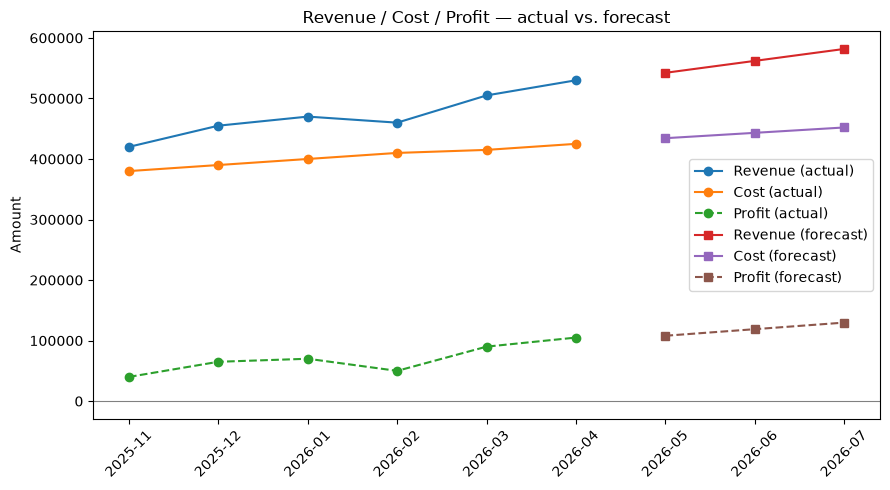

In [ ]:
# --- Sample inputs (edit these for your real business) ----------------------
business_goal = (
    "Launch a festive-season sale campaign for our D2C skincare brand, "
    "find 8 potential retail/distribution partners in India, and tell me "
    "whether we're on track to be profitable next quarter."
)

# Synthetic financial history — replace with your real monthly data
financial_history = pd.DataFrame({
    "month": ["2025-11", "2025-12", "2026-01", "2026-02", "2026-03", "2026-04"],
    "revenue": [420000, 455000, 470000, 460000, 505000, 530000],
    "cost":    [380000, 390000, 400000, 410000, 415000, 425000],
})

demo_inputs = {
    "marketing_agent": dict(
        product="Botanica — natural skincare line",
        audience="Urban Indian women, 22-35, interested in clean beauty",
        platforms=["Instagram", "LinkedIn", "X"],
        goal="Drive festive-season sales and grow brand awareness",
    ),
    "lead_gen_agent": dict(
        icp_description="Boutique retail chains and e-commerce marketplaces open to stocking a new clean-beauty skincare brand",
        industry="beauty & personal care retail",
        region="India",
        max_results=8,
    ),
    "campaign_agent": dict(
        brief="Diwali sale, 20% off, natural skincare brand, festive and premium feel",
        comments=[
            "Does this work for sensitive skin?",
            "When does the sale end?",
            "Do you ship to Bangalore?",
        ],
        filename="poster.png",
    ),
    "revenue_predictor_agent": dict(
        history_df=financial_history,
        periods=3,
    ),
}

result = orchestrator.execute(business_goal, demo_inputs)


### Final compiled report

In [ ]:
print(result["final_report"])


Executive Report: Botanica Festive Campaign, Distribution Pipeline, and Q2 Financial Outlook

To capitalize on the upcoming festive season, Botanica is positioned to execute a targeted multi-channel campaign blending Ayurvedic heritage with modern dermatological science. Promoted under the core tagline "Illuminate Your Purest Festive Glow" with a 20% discount, all creative assets and platform-specific cadences across Instagram, LinkedIn, and X are prepared. The marketing push targets a 35% surge in direct-to-consumer revenue and aims to generate over 200 corporate gifting inquiries via LinkedIn.

To scale offline and online distribution across India, initial partner research has secured tier-one candidates, including Nykaa, Tira (Reliance Retail), Myntra, and Zepto (quick commerce). While these four channels offer strong market alignment, business development efforts must expand to secure the target of eight total distribution partners.

Regarding financial performance, Botanica is fir

### Individual agent outputs (for review / QA before presenting)

In [ ]:
print("--- Marketing strategy ---")
print(json.dumps(result["agent_outputs"]["marketing_agent"], indent=2))


--- Marketing strategy ---
{
  "positioning": "Botanica is the premier clean beauty destination for modern urban Indian women, seamlessly blending time-tested Ayurvedic botanical wisdom with modern dermatological science. Designed for the conscious consumer, Botanica delivers effective, non-toxic, and eco-friendly skincare solutions that unlock your effortless, healthy glow just in time for the festive season.",
  "key_messages": [
    "Celebrate festive celebrations with a natural, toxin-free skin glow powered by pure botanicals.",
    "Ancient botanical heritage meets modern dermatological science for conscious, compromise-free beauty.",
    "Elevate your festive gifting with ethical, sustainable, and luxurious clean skincare sets."
  ],
  "platform_plan": {
    "Instagram": {
      "content_pillars": [
        "Festive GRWM & Skincare Rituals",
        "Ingredient Spotlights & Clean Beauty Myths",
        "UGC, Influencer Unboxings & Giveaways"
      ],
      "posting_cadence": "5x/

In [ ]:
print("--- Qualified leads ---")
result["agent_outputs"]["lead_gen_agent"]


--- Qualified leads ---


,organization,why_it_fits,confidence,likely_contact_channel,source_url
0,Nykaa,Nykaa is a premier Indian e-commerce marketpla...,high,Brand Onboarding Portal / LinkedIn,https://www.indianretailer.com/article/retail-...
1,Tira (Reliance Retail),Tira is Reliance Retail's dedicated omnichanne...,high,Vendor Inquiries / LinkedIn,https://www.personalcareinsights.com/news/indi...
2,Myntra,Myntra is a leading Indian e-commerce marketpl...,medium,Seller Registration Portal / LinkedIn,https://www.nexdigm.com/market-research/report...
3,Zepto,Zepto is an Indian quick-commerce platform exp...,medium,Brand Partnerships Email / LinkedIn,https://www.instagram.com/p/DMc2Xi4z8r8


--- Campaign poster ---
{
  "headline": "Illuminate Your Purest Festive Glow",
  "subheadline": "Celebrate Diwali with 20% off our luxury natural skincare collection.",
  "cta": "Shop The Festive Sale",
  "mood": "premium"
}


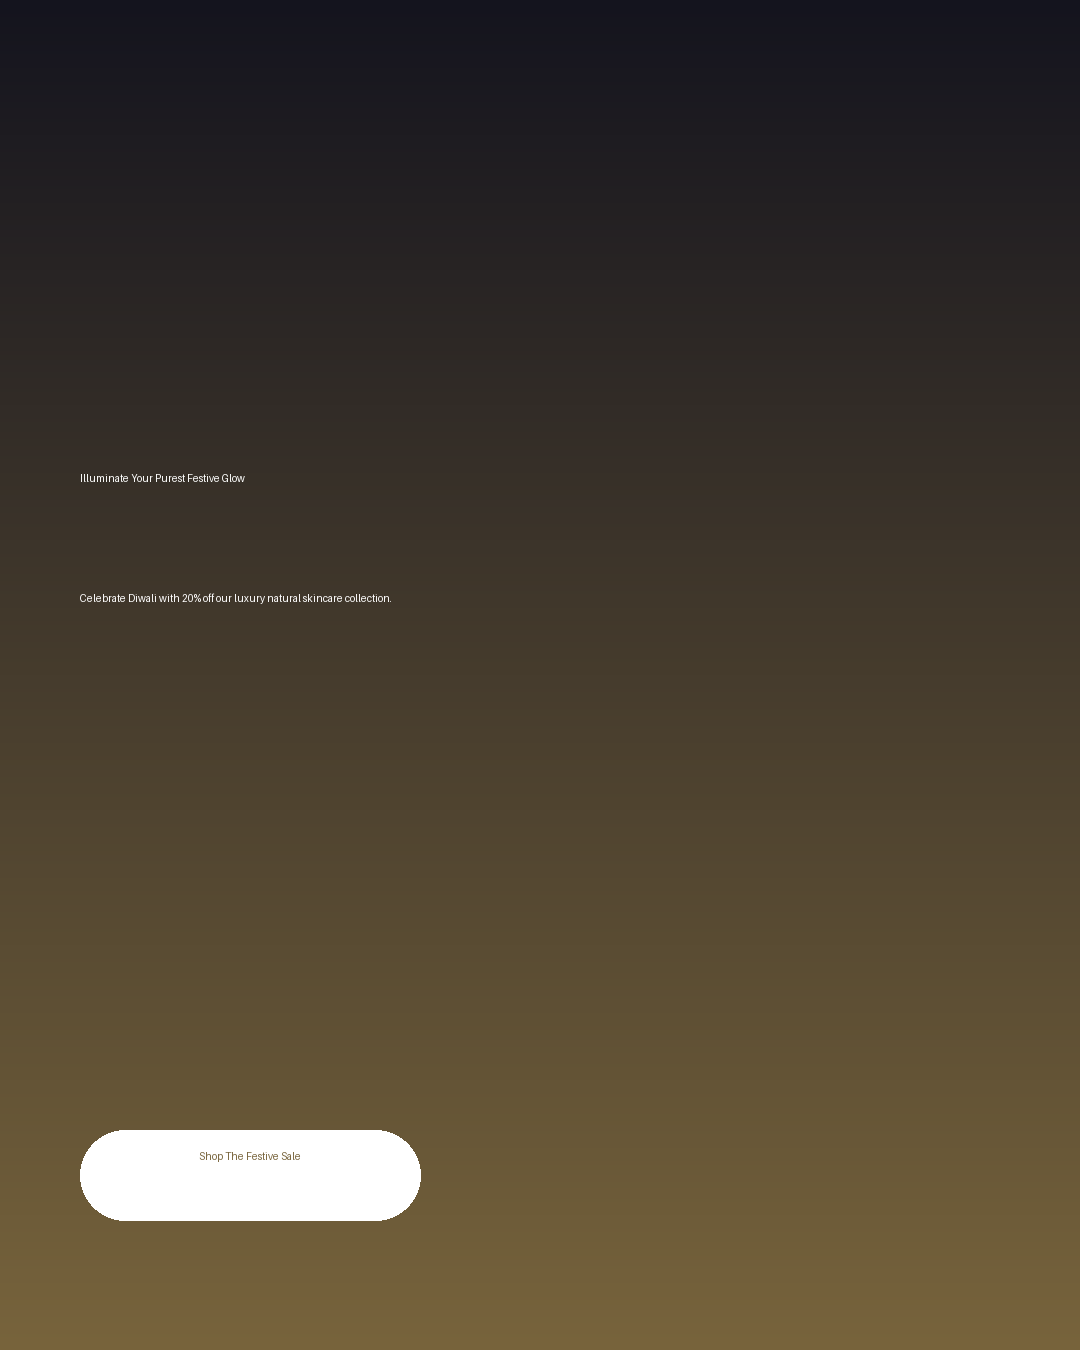

In [ ]:
print("--- Campaign poster ---")
poster_result = result["agent_outputs"]["campaign_agent"]
print(json.dumps(poster_result["copy"], indent=2))
Image.open(poster_result["poster_path"])


In [ ]:
print("--- Engagement replies ---")
print(json.dumps(poster_result["replies"], indent=2))


--- Engagement replies ---
[
  "Yes, it does! Our products are formulated to be gentle on sensitive skin, but we always recommend doing a patch test first.",
  "Our sale ends this Sunday at midnight! Make sure to grab your favorites before then.",
  "Yes, we do! We ship all across India, including Bangalore. Happy shopping!"
]


In [ ]:
print("--- Revenue forecast ---")
rev_result = result["agent_outputs"]["revenue_predictor_agent"]
display(rev_result["forecast"])
print()
print(rev_result["summary"])


--- Revenue forecast ---


,month,revenue,cost,profit
0,2026-05,542333.0,434333.0,108000.0
1,2026-06,562048.0,443190.0,118858.0
2,2026-07,581762.0,452048.0,129714.0



Executive Summary

The financial performance demonstrates a strong, steady growth trajectory across all months. Historical revenue grew from $420,000 in November 2025 to $530,000 in April 2026, and linear projections indicate continued growth reaching $581,762 by July 2026.

The business is projected to remain consistently profitable throughout the upcoming three-month forecast window (May to July 2026). Net profits are expected to expand steadily from $108,000 in May to $118,858 in June and $129,714 in July 2026, as projected top-line revenue growth continues to outpace rising operational costs.

A key risk to monitor is steady cost expansion coupled with revenue volatility. Costs increased continuously from $380,000 to $425,000 historically, while revenue experienced a temporary dip in February 2026. If operational cost growth accelerates beyond forecast assumptions, profit margins will compress.

We recommend implementing strict expense oversight to cap rising operational costs whi

## Limitations & next steps (good to mention when presenting this)

- **Poster generation** is template-based (Pillow), not AI-illustrated artwork — true image generation (Imagen, Stable Diffusion, etc.) needs a paid tier or GPU. Easy to swap in later.
- **Lead generation** quality depends on what's publicly indexed on the web; for a real CRM-grade pipeline, add LinkedIn Sales Navigator or Crunchbase as additional sources.
- **Revenue forecasting** uses a simple linear trend for transparency and speed. For a more rigorous forecast, swap in seasonal models (e.g. Prophet, ARIMA) once you have 18+ months of data.
- **Scaling up:** this custom orchestrator can be swapped for a framework like LangGraph or CrewAI without changing the individual agent classes — they were written with a plain `.run()` interface specifically so that migration is a drop-in change.
- **Rate limits:** the free Gemini tier is limited in requests per minute; `call_gemini()` already retries with backoff, but for heavy batch use (e.g. 100+ leads) add a short `time.sleep()` between calls.
